# CÓDIGO 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Importar los archivos
company_trips = pd.read_csv("/datasets/project_sql_result_01.csv")
dropoff_trips = pd.read_csv("/datasets/project_sql_result_04.csv")

# Ver las primeras filas
print(company_trips.head())
print()
print(dropoff_trips.head())

# Estudiar la información general de los datasets
print(company_trips.info())
print()
print(dropoff_trips.info())

# Revisar valores ausentes
print(company_trips.isna().sum())
print()
print(dropoff_trips.isna().sum())

# Revisar duplicados
print(company_trips.duplicated().sum())
print(dropoff_trips.duplicated().sum())

# Asegurar que los tipos de datos sean correctos
company_trips["trips_amount"] = company_trips["trips_amount"].astype(int)
dropoff_trips["average_trips"] = dropoff_trips["average_trips"].astype(float)

# Identificar los 10 principales barrios por finalización de viajes
top_10_dropoffs = dropoff_trips.sort_values(
    by="average_trips",
    ascending=False
).head(10)

print(top_10_dropoffs)

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count 

# GráficO 1

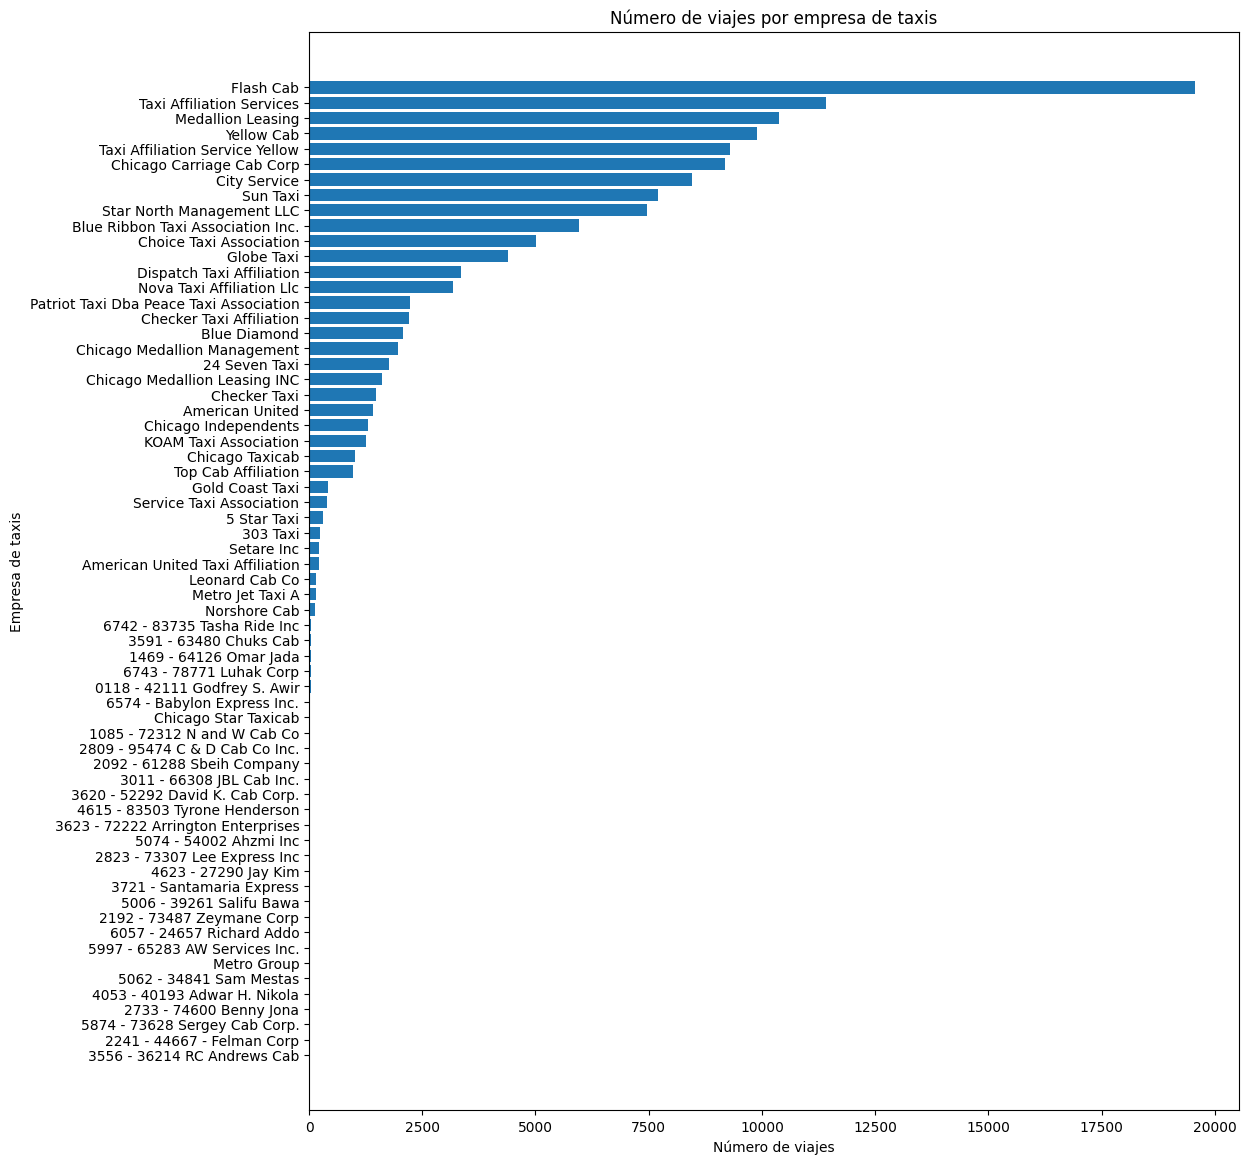

In [2]:
# empresas de taxis y número de viajes
company_trips_sorted = company_trips.sort_values(
    by="trips_amount",
    ascending=False
)

plt.figure(figsize=(12, 14))
plt.barh(
    company_trips_sorted["company_name"],
    company_trips_sorted["trips_amount"]
)
plt.gca().invert_yaxis()
plt.title("Número de viajes por empresa de taxis")
plt.xlabel("Número de viajes")
plt.ylabel("Empresa de taxis")
plt.show()

# Gráfico 2

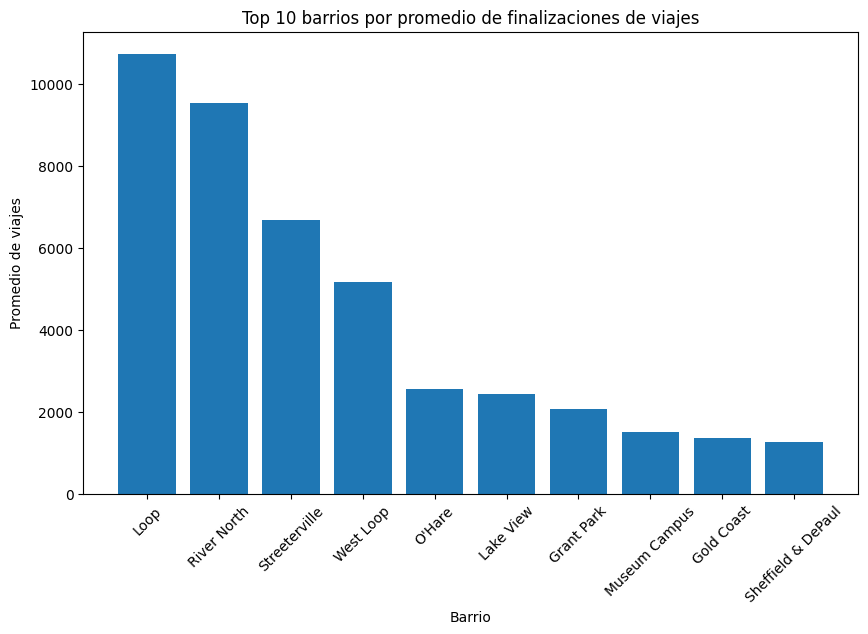

In [3]:
# top 10 barrios por número promedio de finalizaciones
plt.figure(figsize=(10, 6))
plt.bar(
    top_10_dropoffs["dropoff_location_name"],
    top_10_dropoffs["average_trips"]
)
plt.title("Top 10 barrios por promedio de finalizaciones de viajes")
plt.xlabel("Barrio")
plt.ylabel("Promedio de viajes")
plt.xticks(rotation=45)
plt.show()

# Prueba de hipótesis

In [4]:
import pandas as pd
from scipy import stats

# Importar el archivo
rides = pd.read_csv("/datasets/project_sql_result_07.csv")

# Estudiar los datos
print(rides.head())
print()
print(rides.info())
print()
print(rides["weather_conditions"].value_counts())

# Asegurar tipos correctos
rides["start_ts"] = pd.to_datetime(rides["start_ts"])
rides["duration_seconds"] = rides["duration_seconds"].astype(float)

# Separar los viajes según el clima
bad_weather = rides[rides["weather_conditions"] == "Bad"]["duration_seconds"]
good_weather = rides[rides["weather_conditions"] == "Good"]["duration_seconds"]

# Calcular estadísticas descriptivas
print("Cantidad de viajes con mal clima:", len(bad_weather))
print("Cantidad de viajes con buen clima:", len(good_weather))
print("Duración promedio con mal clima:", bad_weather.mean())
print("Duración promedio con buen clima:", good_weather.mean())

# Prueba de hipótesis
alpha = 0.05

results = stats.ttest_ind(
    bad_weather,
    good_weather,
    equal_var=False
)

print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None

Good    888
Bad     180
Name: weather_conditions, dtype: int64
Cantidad de viajes con mal clima: 180
Cantidad de viajes con buen clima: 888
Duración promedio con mal clima: 2427.2055555555557
Duración promedio con buen clima: 199

## Datos:

Viajes con buen clima: 888
Viajes con mal clima: 180

Duración promedio con buen clima: 1999.68 segundos
Duración promedio con mal clima: 2427.21 segundos
Diferencia aproximada: 427.53 segundos
p-value: 6.70e-12

## Hipótesis nula, H0: 

La duración promedio de los viajes desde Loop hasta O'Hare es igual en sábados con buen clima y sábados con mal clima.

## Hipótesis alternativa, H1:

La duración promedio de los viajes desde Loop hasta O'Hare cambia en sábados con mal clima.


## Criterio usado

Se utilizó una prueba t para dos muestras independientes, porque comparamos la duración promedio de dos grupos distintos:

* viajes con clima Good
* viajes con clima Bad
* 
Usamos equal_var=False, es decir, la prueba t de Welch, porque los grupos tienen tamaños diferentes y no es necesario asumir que sus varianzas son iguales.

## Conclusión de la hipótesis

Con un nivel de significación de alpha = 0.05, el p-value obtenido es aproximadamente 6.70e-12, mucho menor que 0.05. Por lo tanto, se rechaza la hipótesis nula.

Esto significa que existe evidencia estadísticamente significativa para afirmar que la duración promedio de los viajes desde Loop hasta el Aeropuerto Internacional O’Hare cambia los sábados con mal clima. Además, en los datos analizados, los viajes con mal clima tienen una duración promedio mayor: aproximadamente 2427 segundos, frente a 2000 segundos en días con buen clima. La diferencia es de unos 428 segundos, es decir, alrededor de 7 minutos más.

Desde una perspectiva de negocio, esto indica que el clima es un factor relevante para Zuber. En sábados con lluvia o tormenta, los viajes hacia O’Hare tienden a tardar más, por lo que la empresa debería considerar estas condiciones al estimar tiempos de llegada, asignar conductores y planificar la disponibilidad del servicio.

# ANÁLISIS 

### Análisis del gráfico de empresas de taxis

El gráfico muestra una concentración importante de viajes en un grupo reducido de compañías. Flash Cab lidera claramente el mercado con 19,558 viajes durante el 15 y 16 de noviembre de 2017, seguida por Taxi Affiliation Services con 11,422 viajes y Medallion Leasin con 10,367 viajes. Esta diferencia indica que Flash Cab tenía una presencia operativa considerablemente mayor que sus competidores directos en el periodo analizado.

También se observa que varias empresas, como Yellow Cab, Taxi Affiliation Service Yellow, Chicago Carriage Cab Corp, City Service y Sun Taxi, mantienen volúmenes relevantes, aunque por debajo del grupo líder. Sin embargo, después de las primeras compañías, la cantidad de viajes disminuye de forma marcada. Esto sugiere que el mercado de taxis en Chicago está parcialmente concentrado: unas pocas empresas realizan una proporción elevada de los viajes, mientras que muchas compañías pequeñas tienen una participación mucho menor.

Desde la perspectiva de Zuber, este patrón es importante porque permite identificar a los principales competidores. Flash Cab, Taxi Affiliation Services y Medallion Leasin deberían considerarse referentes clave para analizar cobertura, disponibilidad de vehículos, posicionamiento y capacidad operativa. Además, la presencia de muchas empresas con bajo volumen podría representar una oportunidad para Zuber si logra ofrecer un servicio más eficiente o diferenciado.

### Análisis del gráfico de los 10 principales barrios de destino

El segundo gráfico muestra los barrios con mayor promedio de viajes finalizados durante noviembre de 2017. Loop ocupa el primer lugar con un promedio aproximado de 10,727 viajes, seguido por River North con 9,524 y Streeterville con 6,665. Estos resultados evidencian una fuerte concentración de destinos en zonas céntricas y de alta actividad urbana.

La presencia de barrios como Loop, River North, Streeterville y West Loop sugiere que una gran parte de la demanda se relaciona con áreas comerciales, oficinas, hoteles, restaurantes, turismo y entretenimiento. Estos sectores suelen generar un flujo constante de pasajeros durante diferentes momentos del día, lo que los convierte en zonas estratégicas para empresas de transporte.

También destaca O’Hare, que aparece dentro de los cinco principales destinos. Esto es relevante porque los aeropuertos suelen concentrar viajes de mayor distancia y posiblemente de mayor valor económico. Para Zuber, esta información puede ser útil al diseñar estrategias de disponibilidad de conductores cerca de zonas de alta demanda y rutas frecuentes hacia el aeropuerto.

En conjunto, los datos muestran que la demanda de viajes no está distribuida de manera uniforme en toda la ciudad. Por el contrario, se concentra en zonas específicas con alta actividad económica, turística y de transporte. Para una empresa nueva como Zuber, esto implica que una estrategia inicial podría enfocarse en cubrir de manera eficiente los barrios con mayor volumen de finalizaciones, especialmente Loop, River North, Streeterville, West Loop y O’Hare.

## Conclusión general del análisis exploratorio

El análisis exploratorio revela dos patrones principales. Primero, el mercado de taxis presenta una estructura competitiva concentrada, donde pocas empresas dominan una gran parte de los viajes. Segundo, la demanda de destinos se concentra en barrios céntricos y zonas estratégicas como el aeropuerto O’Hare.

Para Zuber, estos hallazgos son relevantes porque permiten identificar tanto a los competidores más fuertes como las áreas geográficas con mayor demanda potencial. Una estrategia de entrada al mercado podría priorizar la disponibilidad de vehículos en zonas como Loop, River North y Streeterville, además de fortalecer la cobertura hacia y desde O’Hare. Esto permitiría competir en los segmentos con mayor volumen de pasajeros y mejorar la eficiencia operativa desde el inicio.